In [1]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import sys
sys.path.append('..')
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 1 / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 200517.73350671504
C6 190000.0
beta (a0) 525.3927746085943
E_beta (K) 2.852507331186637e-06
tau_beta (s) 2.677725627038548e-06


In [14]:
r_match = 1 * beta
print(E_beta)
print(c6 / r_match ** 6 / E_beta)

9.03335391081193e-12
1.0000000000000004


In [3]:
num_samples = 5000

scale = 1

# properties of resonant spectrum
rrkm = 0.25e-3     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale
print("mean spacing (E6)", mean_spacing)

# thermal properties
temp = 1 / scale       # in terms of E6
num_resonances = 1000        # should be odd
print("T/d", temp / mean_spacing)

rrkm_c6 = 2 * np.pi / mean_spacing 
print("RRKM (tau_beta)", rrkm_c6)
print("RRKM (s)", rrkm_c6 * tau_beta * tau0 / scale)

mean spacing (E6) 0.06729858526586742
T/d 14.859153369263785
RRKM (tau_beta) 93.36281412688626
RRKM (s) 0.00024999999999999995


In [4]:
mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

In [5]:
hbar = 1
std_k = 1 / 3
std_x = 1 / std_k
print(std_x)
x0 = 200
print(x0)
k0 = 1
print(temp)
print(k0)
print(200 / (2 * k0))

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

3.0
200
1.0
1
100.0


(999,)


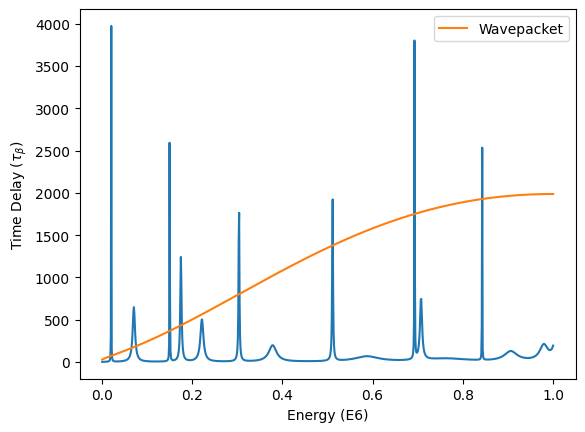

In [6]:
energy_grid = np.linspace(0, 1 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2, label="Wavepacket")
# plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_\beta$)")
# plt.savefig("gif_wavepacket.pdf")
plt.show()

In [7]:
xs = np.linspace(-5000, 0, 10001)
dx = xs[1] - xs[0]

ps = np.linspace(k0 - 4 * std_k, k0 + 4 * std_k, 20001)
dp = ps[1] - ps[0]
print(dp)
ps = ps.reshape((len(ps), 1))

0.00013333333333331865


In [8]:
fluxes = []
fluxes_nores = []

r1 = lambda k : 1 #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
psi1 = []

incoming_envelope = gaussian_envelope(ps) / np.sqrt(2 * np.pi) * np.exp(1j * ps * xs)
outgoing_envelope = gaussian_envelope(ps) / np.sqrt(2 * np.pi) * np.exp(-1j * ps * xs)

In [9]:
import pickle 
from tqdm import tqdm

distances = []
totals = []

for i in tqdm(range(1000)):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    
    r2 = lambda k : np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))

    psi2 = []
    reflected_envelope_2 = r2(ps) * outgoing_envelope
    total_envelope_2 = incoming_envelope + reflected_envelope_2
        
    wave2 = np.sum(total_envelope_2, axis=0) * dp

    total2 = np.sum(np.abs(wave2) ** 2).item()
    totals.append(total2)

    x2 = np.sum(np.abs(wave2) ** 2 * xs) / total2

    distances.append(x2.item())

with open("dense_wavepacket.pkl", "wb") as f:
    pickle.dump(distances, f)

100%|██████████| 1000/1000 [14:27<00:00,  1.15it/s]


In [10]:
print(totals)
print(distances)

[1.9931832435986594, 1.9930601764812594, 1.9961737381997988, 1.9968001231611454, 1.993552273519988, 1.9949745855796417, 1.9934112886801945, 1.992634319348157, 1.9931926887789448, 1.9955462926500387, 1.9965929530565152, 1.9945427868413765, 1.9962835735646802, 1.9963955835486114, 1.9970476466567233, 1.996200090943236, 1.9946679728956707, 1.993500282761778, 1.994608551860444, 1.994844944386908, 1.99576908156468, 1.9951358961945767, 1.9971279448453543, 1.9935663387238933, 1.9940408603787958, 1.9952369530758745, 1.9957964217648558, 1.997267060852452, 1.9958022412844012, 1.9959427343102187, 1.9928133691800798, 1.9919636198590267, 1.9975677507349563, 1.9939692223076595, 1.9947201547247955, 1.9942918729767105, 1.9947169344187794, 1.9955095238632679, 1.9947512712945141, 1.995116742418801, 1.9930064194390762, 1.9972398602022177, 1.9958290877503102, 1.997395714533618, 1.9963792984472182, 1.9933599849806345, 1.99313846633711, 1.996331574321785, 1.996174048147758, 1.9952118965607528, 1.996257916632

In [6]:
import cupy as np
import pickle
with open("dense_wavepacket.pkl", "rb") as f:
    distances = pickle.load(f)

93.36281412688626
0.8164885875571681
8.189615467435685


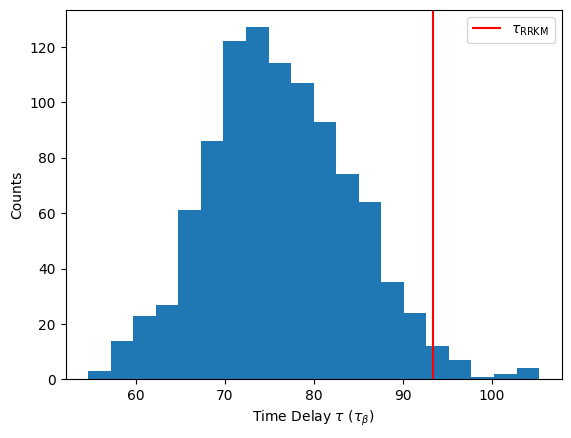

In [28]:
diff_dist = -x0 - np.array(distances) 
rrkm_c6 = 2 * np.pi / mean_spacing 
print(rrkm_c6)

plt.hist(diff_dist.get() / 2 / k0, bins=20)
plt.axvline(rrkm_c6, color="red", label=r"$\tau_{\text{RRKM}}$")
plt.xlabel(r"Time Delay $\tau\ (\tau_\beta)$")
plt.ylabel("Counts")
print(np.mean(np.array(diff_dist.get() / 2 / k0 / rrkm_c6).get()))
print(np.std(np.array(diff_dist.get() / 2 / k0).get()))
# plt.title(r"$k_bT=1\ E_\beta$")
plt.legend()
plt.savefig("dense_wavepacket.pdf")
plt.show()